In [1]:
import os
import csv
import sys
import time
import json
import typing as t  
import requests
import pandas as pd
import numpy as np
from typing import Dict, Iterable, Optional
from pathlib import Path
import mplfinance as mpf
import matplotlib.pyplot as plt
from utils import *
 


Using cuda (NVIDIA GeForce RTX 2060)


In [2]:
# models
model_names = ["baseline_random_distribution",  "baseline_mean", "baseline_zero"]

# read metrics
data = {}
for model_name in model_names:
    
    with open(RESULTS_PATH + "/metrics_" + model_name + ".json", "r") as f:
        metrics = json.load(f)
        data[model_name] = {"metrics": metrics}

    print(model_name + "(train)")
    data[model_name]["train"]= pd.read_pickle(RESULTS_PATH + "/data_" + model_name + "_train.pkl")
    
    print(model_name + "(validation)")
    data[model_name]["validation"] = pd.read_pickle(RESULTS_PATH + "/data_" + model_name + "_validation.pkl")
    
    print(model_name + "(test)")
    data[model_name]["test"] = pd.read_pickle(RESULTS_PATH + "/data_" + model_name + "_test.pkl")
    

baseline_random_distribution(train)
baseline_random_distribution(validation)
baseline_random_distribution(test)
baseline_mean(train)
baseline_mean(validation)
baseline_mean(test)
baseline_zero(train)
baseline_zero(validation)
baseline_zero(test)


In [3]:
# obtiene todas las metricas
rows = []
for model_name, model_data in data.items():
    for phase in ['train', 'validation', 'test']:
        metrics = model_data["metrics"]
        metrics_phase = metrics[phase]
        rows.append({
            'Model': model_name,
            'Phase': phase,
            'Train_MS': metrics['train_ms'],
            'Predict_MS': metrics['test_predict_ms'],
            'MSE': metrics_phase['mse'],
            'RMSE': metrics_phase['rmse'],
            'MAE': metrics_phase['mae'],
            'R2': metrics_phase['r2'],
            'Direction': metrics_phase['direction'],
            'Sharpe': metrics_phase['sharpe']
        })
df = pd.DataFrame(rows)        

# muestra las de train
df_train = df[df["Phase"] == "train"]
df_train = df_train[["Model","MSE","RMSE","MAE","R2","Direction","Sharpe","Train_MS","Predict_MS"]]
display(df_train)

# muestra las de validation
df_validation = df[df["Phase"] == "validation"]
df_validation = df_validation[["Model","MSE","RMSE","MAE","R2","Direction","Sharpe","Train_MS","Predict_MS"]]
display(df_validation)

# muestra las de test
df_test = df[df["Phase"] == "test"]
df_test = df_test[["Model","MSE","RMSE","MAE","R2","Direction","Sharpe","Train_MS","Predict_MS"]]
display(df_test)
# muestra los tiempos de train, + predict



,Model,MSE,RMSE,MAE,R2,Direction,Sharpe,Train_MS,Predict_MS
0,baseline_random_distribution,0.000010,0.003101,0.002070,-0.461834,40.658035,-0.015319,0.0,0.0
3,baseline_mean,0.000007,0.002565,0.001253,0.000000,55.932967,NaN,0.0,0.0
6,baseline_zero,0.000007,0.002565,0.001232,-0.000230,55.932967,NaN,0.0,0.0


,Model,MSE,RMSE,MAE,R2,Direction,Sharpe,Train_MS,Predict_MS
1,baseline_random_distribution,0.000007,0.002637,0.001802,-0.683511,41.666667,0.015045,0.0,0.0
4,baseline_mean,0.000004,0.002033,0.000979,-0.000355,57.033639,NaN,0.0,0.0
7,baseline_zero,0.000004,0.002034,0.000959,-0.001441,57.033639,NaN,0.0,0.0


,Model,MSE,RMSE,MAE,R2,Direction,Sharpe,Train_MS,Predict_MS
2,baseline_random_distribution,0.000008,0.002873,0.001934,-0.583155,40.746353,-0.01477,0.0,0.0
5,baseline_mean,0.000005,0.002284,0.001091,-0.000008,56.753173,NaN,0.0,0.0
8,baseline_zero,0.000005,0.002284,0.001071,-0.000395,56.753173,NaN,0.0,0.0


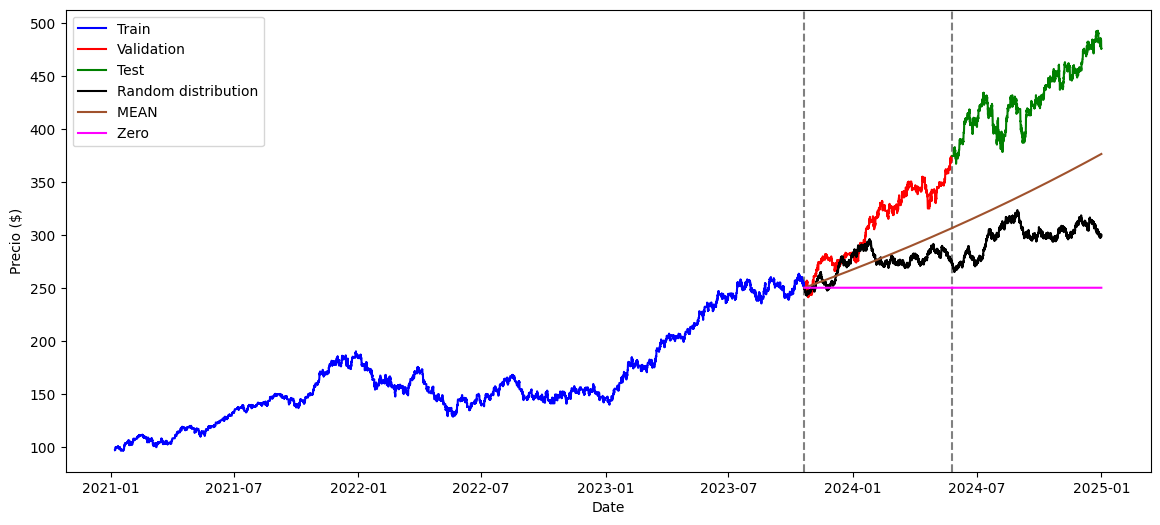

In [ ]:
# plot prices acumulated
model_name = "baseline_random_distribution"
model_data = data[model_name]
df_scaled_window_train = model_data["train"].reset_index()
df_scaled_window_validation = model_data["validation"].reset_index()
df_scaled_window_test = model_data["test"].reset_index()


plt.figure(figsize=(14,6))
plt.axvline(df_scaled_window_validation.iloc[0][DATETIME_COL], color='gray', linestyle='--')
plt.axvline(df_scaled_window_test.iloc[0][DATETIME_COL], color='gray', linestyle='--')

plt.plot(df_scaled_window_train[DATETIME_COL], df_scaled_window_train["close"], label="Train", color="blue")
plt.plot(df_scaled_window_validation[DATETIME_COL], df_scaled_window_validation["close"], label="Validation", color="red")
plt.plot(df_scaled_window_test[DATETIME_COL], df_scaled_window_test["close"], label="Test", color="green")

# random distribution
color = "black"
model_name = "baseline_random_distribution"
model_data = data[model_name]
df_scaled_window_train = model_data["train"].reset_index()
df_scaled_window_validation = model_data["validation"].reset_index()
df_scaled_window_test = model_data["test"].reset_index()
plt.plot(df_scaled_window_validation[DATETIME_COL], df_scaled_window_validation["predict_close_accumulated"], color=color)
plt.plot(df_scaled_window_test[DATETIME_COL], df_scaled_window_test["predict_close_accumulated"], label="Random distribution", color=color)

# mean
color = "#A0522D"
model_name = "baseline_mean"
model_data = data[model_name]
df_scaled_window_train = model_data["train"].reset_index()
df_scaled_window_validation = model_data["validation"].reset_index()
df_scaled_window_test = model_data["test"].reset_index()
plt.plot(df_scaled_window_validation[DATETIME_COL], df_scaled_window_validation["predict_close_accumulated"], color=color)
plt.plot(df_scaled_window_test[DATETIME_COL], df_scaled_window_test["predict_close_accumulated"], label="MEAN ", color=color)

# zero
color = "#FF00FF"
model_name = "baseline_zero"
model_data = data[model_name]
df_scaled_window_train = model_data["train"].reset_index()
df_scaled_window_validation = model_data["validation"].reset_index()
df_scaled_window_test = model_data["test"].reset_index()
plt.plot(df_scaled_window_validation[DATETIME_COL], df_scaled_window_validation["predict_close_accumulated"], color=color)
plt.plot(df_scaled_window_test[DATETIME_COL], df_scaled_window_test["predict_close_accumulated"], label="Zero ", color=color)


plt.xlabel("Date")
plt.ylabel("Precio ($)")
plt.legend()
plt.show()

In [5]:
# models
model_names = ["baseline_random_distribution", "baseline_random_uniform", "baseline_mean", "baseline_zero"]
model_names = ["LSTM", "NBEATS", "TSFEDL"]

# read metrics
data = {}
for model_name in model_names:
    
    with open(RESULTS_PATH + "/metrics_" + model_name + ".json", "r") as f:
        metrics = json.load(f)
        data[model_name] = {"metrics": metrics}

    print(model_name + "(train)")
    data[model_name]["train"]= pd.read_pickle(RESULTS_PATH + "/data_" + model_name + "_train.pkl")
    
    print(model_name + "(validation)")
    data[model_name]["validation"] = pd.read_pickle(RESULTS_PATH + "/data_" + model_name + "_validation.pkl")
    
    print(model_name + "(test)")
    data[model_name]["test"] = pd.read_pickle(RESULTS_PATH + "/data_" + model_name + "_test.pkl")
    

LSTM(train)
LSTM(validation)
LSTM(test)
NBEATS(train)
NBEATS(validation)
NBEATS(test)
TSFEDL(train)
TSFEDL(validation)
TSFEDL(test)


In [ ]:
# obtiene todas las metricas
rows = []
for model_name, model_data in data.items():
    for phase in ['train', 'validation', 'test']:
        metrics = model_data["metrics"]
        metrics_phase = metrics[phase]
        rows.append({
            'Model': model_name,
            'Phase': phase,
            'Train_MS': metrics['train_ms'],
            'Predict_MS': metrics['test_predict_ms'],
            'MSE': metrics_phase['mse'],
            'RMSE': metrics_phase['rmse'],
            'MAE': metrics_phase['mae'],
            'R2': metrics_phase['r2'],
            'Direction': metrics_phase['direction'],
            'Sharpe': metrics_phase['sharpe']
        })
df = pd.DataFrame(rows)        

# muestra las de train
df_train = df[df["Phase"] == "train"]
df_train = df_train[["Model","MSE","RMSE","MAE","R2","Direction","Sharpe","Train_MS","Predict_MS"]]
display(df_train)

# muestra las de validation
df_validation = df[df["Phase"] == "validation"]
df_validation = df_validation[["Model","MSE","RMSE","MAE","R2","Direction","Sharpe","Train_MS","Predict_MS"]]
display(df_validation)

# muestra las de test
df_test = df[df["Phase"] == "test"]
df_test = df_test[["Model","MSE","RMSE","MAE","R2","Direction","Sharpe","Train_MS","Predict_MS"]]
display(df_test)



,Model,MSE,RMSE,MAE,R2,Direction,Sharpe,Train_MS,Predict_MS
0,LSTM,0.000007,0.002563,0.001270,0.001165,57.756289,0.028991,143.876408,2.413915
3,NBEATS,0.000006,0.002427,0.001203,0.106266,69.357146,0.176267,20.330036,15.363170
6,TSFEDL,0.000007,0.002556,0.001248,0.006734,65.221667,0.056332,232.120200,0.938208


,Model,MSE,RMSE,MAE,R2,Direction,Sharpe,Train_MS,Predict_MS
1,LSTM,0.000004,0.002031,0.000982,0.001576,63.226300,0.026718,143.876408,2.413915
4,NBEATS,0.000005,0.002165,0.001194,-0.134900,43.367737,-0.008371,20.330036,15.363170
7,TSFEDL,0.000004,0.002030,0.000981,0.002183,64.487768,0.039196,232.120200,0.938208


,Model,MSE,RMSE,MAE,R2,Direction,Sharpe,Train_MS,Predict_MS
2,LSTM,0.000005,0.002282,0.001083,0.001273,60.655427,0.026263,143.876408,2.413915
5,NBEATS,0.000006,0.002387,0.001189,-0.092777,67.474901,0.054589,20.330036,15.363170
8,TSFEDL,0.000005,0.002283,0.001095,0.000780,60.276568,0.030281,232.120200,0.938208


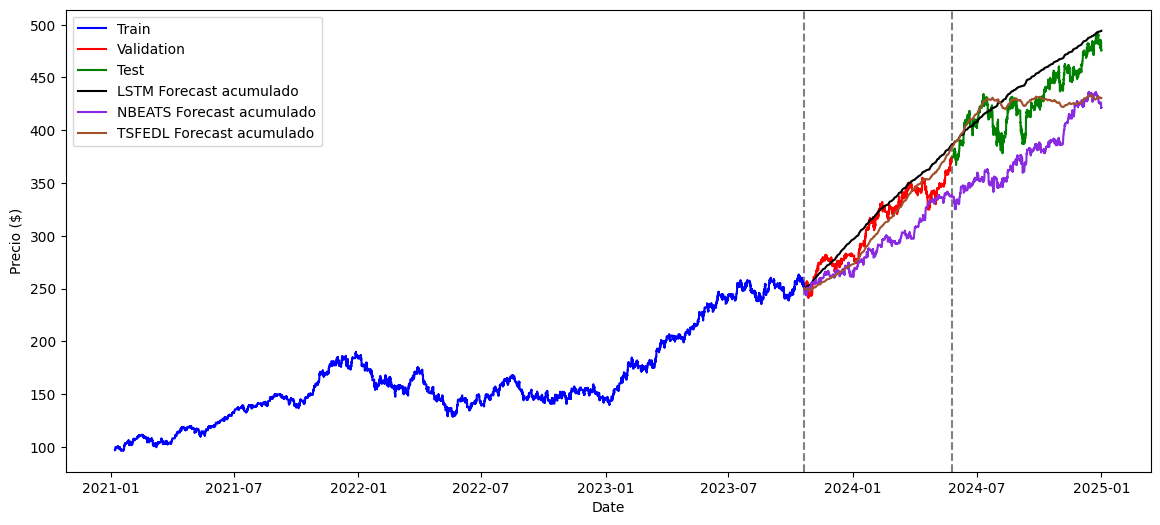

In [ ]:
# plot prices acumulated
model_name = "LSTM"
model_data = data[model_name]
df_scaled_window_train = model_data["train"].reset_index()
df_scaled_window_validation = model_data["validation"].reset_index()
df_scaled_window_test = model_data["test"].reset_index()

plt.figure(figsize=(14,6))
plt.axvline(df_scaled_window_validation.iloc[0][DATETIME_COL], color='gray', linestyle='--')
plt.axvline(df_scaled_window_test.iloc[0][DATETIME_COL], color='gray', linestyle='--')

plt.plot(df_scaled_window_train[DATETIME_COL], df_scaled_window_train["close"], label="Train", color="blue")
plt.plot(df_scaled_window_validation[DATETIME_COL], df_scaled_window_validation["close"], label="Validation", color="red")
plt.plot(df_scaled_window_test[DATETIME_COL], df_scaled_window_test["close"], label="Test", color="green")

# random distribution
color = "black"
model_name = "LSTM"
model_data = data[model_name]
df_scaled_window_train = model_data["train"].reset_index()
df_scaled_window_validation = model_data["validation"].reset_index()
df_scaled_window_test = model_data["test"].reset_index()
plt.plot(df_scaled_window_validation[DATETIME_COL], df_scaled_window_validation["predict_close_accumulated"], color=color)
plt.plot(df_scaled_window_test[DATETIME_COL], df_scaled_window_test["predict_close_accumulated"], label="LSTM Forecast acumulado", color=color)

# random uniform
color = "#8A2BE2"
model_name = "NBEATS"
model_data = data[model_name]
df_scaled_window_train = model_data["train"].reset_index()
df_scaled_window_validation = model_data["validation"].reset_index()
df_scaled_window_test = model_data["test"].reset_index()
plt.plot(df_scaled_window_validation[DATETIME_COL], df_scaled_window_validation["predict_close_accumulated"], color=color)
plt.plot(df_scaled_window_test[DATETIME_COL], df_scaled_window_test["predict_close_accumulated"], label="NBEATS Forecast acumulado", color=color)

# mean
color = "#A0522D"
model_name = "TSFEDL"
model_data = data[model_name]
df_scaled_window_train = model_data["train"].reset_index()
df_scaled_window_validation = model_data["validation"].reset_index()
df_scaled_window_test = model_data["test"].reset_index()
plt.plot(df_scaled_window_validation[DATETIME_COL], df_scaled_window_validation["predict_close_accumulated"], color=color)
plt.plot(df_scaled_window_test[DATETIME_COL], df_scaled_window_test["predict_close_accumulated"], label="TSFEDL Forecast acumulado", color=color)

plt.xlabel("Date")
plt.ylabel("Precio ($)")
plt.legend()
plt.show()

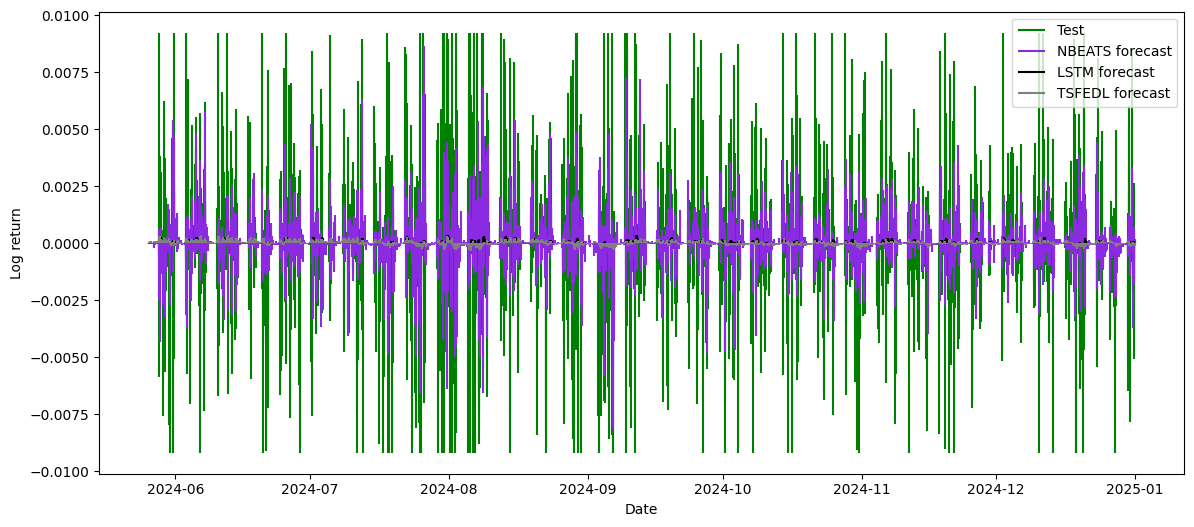

In [8]:
# plot prices acumulated
model_name = "NBEATS"
model_data = data[model_name]
df_scaled_window_train = model_data["train"].reset_index()
df_scaled_window_validation = model_data["validation"].reset_index()
df_scaled_window_test = model_data["test"].reset_index()

# plot log_return test only
plt.figure(figsize=(14,6))
plt.vlines(df_scaled_window_test[DATETIME_COL], ymin=0, ymax=df_scaled_window_test["target_log_return"], label="Test", color="green")

plt.vlines(df_scaled_window_test[DATETIME_COL], ymin=0, ymax=df_scaled_window_test["predict_log_return"], label="NBEATS forecast", color="#8A2BE2")


color = "black"
model_name = "LSTM"
model_data = data[model_name]
df_scaled_window_train = model_data["train"].reset_index()
df_scaled_window_validation = model_data["validation"].reset_index()
df_scaled_window_test = model_data["test"].reset_index()
plt.vlines(df_scaled_window_test[DATETIME_COL], ymin=0, ymax=df_scaled_window_test["predict_log_return"], label="LSTM forecast", color=color)

color = "gray"
model_name = "TSFEDL"
model_data = data[model_name]
df_scaled_window_train = model_data["train"].reset_index()
df_scaled_window_validation = model_data["validation"].reset_index()
df_scaled_window_test = model_data["test"].reset_index()
plt.vlines(df_scaled_window_test[DATETIME_COL], ymin=0, ymax=df_scaled_window_test["predict_log_return"], label="TSFEDL forecast", color=color)


plt.xlabel("Date")
plt.ylabel("Log return")
#plt.title("Test / Test Forecast")
plt.legend()
plt.show()